In [1]:
# 1 — Setup: two-year call base with berth and operation times
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

candidates = [Path.cwd(), *Path.cwd().parents]
BASE = next((p for p in candidates if (p / "data" / "processed").exists()), None)
if BASE is None:
    raise FileNotFoundError(f"data/processed not found from {Path.cwd()} - run from inside the project folder.")
PROC, RAW = BASE / "data" / "processed", BASE / "data" / "raw"

calls = pd.read_csv(PROC / "calls_2024_2025.csv", parse_dates=["ts_arrival", "ts_berth", "ts_unberth"])
ops = pd.concat([pd.read_csv(RAW / f"antaq_{y}_atracacao.txt", sep=";", encoding="utf-8-sig", dtype=str,
                             usecols=["IDAtracacao", "Data Início Operação", "Data Término Operação"])
                 for y in (2024, 2025)])
ops.columns = ["call_id", "ts_ops_start", "ts_ops_end"]
ops["call_id"] = ops["call_id"].astype(int)
for c in ["ts_ops_start", "ts_ops_end"]:
    ops[c] = pd.to_datetime(ops[c], format="%d/%m/%Y %H:%M:%S", errors="coerce")
ops = ops.drop_duplicates("call_id")

calls = calls.merge(ops, on="call_id", how="left", validate="1:1")
calls["terminal"] = calls["port"].str.strip() + " | " + calls["terminal_raw"].fillna("").str.strip()
calls["imo"] = pd.to_numeric(calls["imo"], errors="coerce")
hours = lambda a, b: (calls[b] - calls[a]).dt.total_seconds() / 3600
calls["berth_h"] = hours("ts_berth", "ts_unberth")
calls["ops_h"] = hours("ts_ops_start", "ts_ops_end")

lc = calls[calls["navigation"] == "Longo Curso"].copy()
tol = pd.Timedelta(hours=1)
checks = {
    "missing operation times": lc["ops_h"].isna(),
    "operation <= 0 h": lc["ops_h"] <= 0,
    "operation starts before berthing": lc["ts_ops_start"] < lc["ts_berth"] - tol,
    "operation ends after unberthing": lc["ts_ops_end"] > lc["ts_unberth"] + tol,
    "berth time above 10 days": lc["berth_h"] > 240,
    "TEU moved below 50": lc["teu"] < 50,
}
print(f"Deep-sea container calls: {len(lc):,}")
for k, v in checks.items():
    print(f"  {k}: {v.sum():,} ({100 * v.mean():.1f}%)")

Deep-sea container calls: 12,700
  missing operation times: 0 (0.0%)
  operation <= 0 h: 0 (0.0%)
  operation starts before berthing: 0 (0.0%)
  operation ends after unberthing: 0 (0.0%)
  berth time above 10 days: 9 (0.1%)
  TEU moved below 50: 545 (4.3%)


In [2]:
# 2 — Operation-time quality by terminal, and the analysis universe
lc["valid_ops"] = (lc["ops_h"] > 0) & ~(lc["ts_ops_start"] < lc["ts_berth"] - tol) \
                  & ~(lc["ts_ops_end"] > lc["ts_unberth"] + tol) & (lc["berth_h"] <= 240)
lc["teu_per_ops_h"] = lc["teu"] / lc["ops_h"]
lc["ops_share_of_berth_%"] = 100 * lc["ops_h"] / lc["berth_h"]
lc = lc[lc["ts_berth"].between("2024-01-01", "2025-12-14 23:59")]

def quality(d):
    v = d[d["valid_ops"] & (d["teu"] >= 50)]
    return pd.Series({"calls": len(d), "teu_per_call": d["teu"].mean(),
                      "valid_ops_%": 100 * d["valid_ops"].mean(),
                      "ops_share_of_berth_median_%": v["ops_share_of_berth_%"].median(),
                      "teu_per_ops_h_median": v["teu_per_ops_h"].median(),
                      "teu_per_ops_h_p90": v["teu_per_ops_h"].quantile(0.9),
                      "berth_h_median": v["berth_h"].median()})

q = lc.groupby("terminal").apply(quality, include_groups=False)
q = q[q["calls"] >= 200].sort_values("calls", ascending=False)
print(q.round(1).to_string(), "\n")

PROD_TERMINALS = q.index[(q["teu_per_call"] >= 300) & (q["valid_ops_%"] >= 90)].tolist()
print(f"Terminals kept for productivity: {len(PROD_TERMINALS)}")
for t in PROD_TERMINALS:
    print("  ", t)

pdf = lc[lc["terminal"].isin(PROD_TERMINALS) & lc["valid_ops"] & (lc["teu"] >= 50)].copy()
print(f"\nProductivity base: {len(pdf):,} calls")

                                                                                                  calls  teu_per_call  valid_ops_%  ops_share_of_berth_median_%  teu_per_ops_h_median  teu_per_ops_h_p90  berth_h_median
terminal                                                                                                                                                                                                                
Paranaguá | TCP                                                                                  1445.0        1746.6        100.0                         84.9                 110.6              160.3            17.6
Santos | Cais da Santos Brasil (SSZ 16) - Privativo                                              1364.0        2509.7        100.0                         75.7                 125.3              182.5            24.1
Porto Itapoá Terminais Portuários | Porto Itapoá Terminais Portuários                            1297.0        1990.8        100.0  

In [3]:
# 3 — Scale, vessel class and operator: productivity vs same terminal and same volume band
tab = pd.read_csv(PROC / "tabela_completa.csv",
                  usecols=["IMO", "Classe_Navio", "TEU_Capacidade", "Ano_Construcao",
                           "Armador_Operador", "Aliança"]).rename(columns={"IMO": "imo"})
pdf = pdf.merge(tab, on="imo", how="left", validate="m:1")
pdf["year"] = pdf["ts_berth"].dt.year
pdf["week"] = pdf["ts_berth"].dt.to_period("W")
pdf["inertia_h_per_100teu"] = 100 * pdf["ops_h"] / pdf["teu"]
pdf["log_prod"] = np.log(pdf["teu_per_ops_h"])
BANDS = [50, 500, 1000, 1500, 2000, 3000, 5000, np.inf]
pdf["vol_band"] = pd.cut(pdf["teu"], BANDS, right=False,
                         labels=["50-499", "500-999", "1000-1499", "1500-1999", "2000-2999", "3000-4999", "5000+"])

print("Scale effect — productivity by TEU moved per call:")
print(pdf.groupby("vol_band", observed=True).agg(
    calls=("call_id", "size"), ops_h_median=("ops_h", "median"),
    teu_per_ops_h=("teu_per_ops_h", "median"), inertia_h_per_100teu=("inertia_h_per_100teu", "median"))
    .round(1).to_string(), "\n")

g = pdf.groupby(["terminal", "vol_band"], observed=True)["log_prod"]
pdf["ex_prod"] = (pdf["log_prod"] - g.transform("median")).where(g.transform("size") >= 5)

rng = np.random.default_rng(42)
def boot_ci(x, weeks, n_boot=1000):
    d = pd.DataFrame({"x": x, "w": weeks}).dropna()
    groups = [gg["x"].to_numpy() for _, gg in d.groupby("w")]
    k = len(groups)
    meds = [np.median(np.concatenate([groups[j] for j in rng.integers(0, k, k)])) for _ in range(n_boot)]
    return np.percentile(meds, [2.5, 97.5])

pct = lambda v: 100 * (np.exp(v) - 1)
def prod_ranking(df, by, min_calls=100):
    rows = []
    for key, d in df.dropna(subset=[by]).groupby(by):
        if len(d) < min_calls:
            continue
        lo, hi = boot_ci(d["ex_prod"], d["week"])
        rows.append({by: key, "calls": len(d), "teu_per_call": d["teu"].median(),
                     "teu_per_ops_h": d["teu_per_ops_h"].median(),
                     "inertia_h_per_100teu": d["inertia_h_per_100teu"].median(),
                     "vs_same_terminal_volume_%": pct(d["ex_prod"].median()),
                     "CI_low_%": pct(lo), "CI_high_%": pct(hi)})
    return pd.DataFrame(rows).set_index(by).sort_values("vs_same_terminal_volume_%", ascending=False).round(1)

CLASS_ORDER = ["Feeder / Sub-Panamax", "Panamax", "Neo-Panamax", "Large Post-Panamax", "Ultra Large (ULCS)"]
print("By vessel class, 2024 + 2025 (productivity vs same terminal & volume band; + = faster):")
print(prod_ranking(pdf, "Classe_Navio", min_calls=50).reindex(CLASS_ORDER).to_string(), "\n")

print("By vessel operator, 2025:")
print(prod_ranking(pdf[pdf["year"] == 2025], "Armador_Operador").to_string())

Scale effect — productivity by TEU moved per call:
           calls  ops_h_median  teu_per_ops_h  inertia_h_per_100teu
vol_band                                                           
50-499      1179           7.0           44.7                   2.2
500-999     1838          10.2           73.6                   1.4
1000-1499   1908          13.7           89.7                   1.1
1500-1999   1687          16.3          107.0                   0.9
2000-2999   2232          19.9          122.5                   0.8
3000-4999   1474          26.2          140.8                   0.7
5000+        232          36.0          167.9                   0.6 

By vessel class, 2024 + 2025 (productivity vs same terminal & volume band; + = faster):
                      calls  teu_per_call  teu_per_ops_h  inertia_h_per_100teu  vs_same_terminal_volume_%  CI_low_%  CI_high_%
Classe_Navio                                                                                                            

In [4]:
# 4 — Q11: Neo-Panamax vs Panamax moving similar volumes at the same terminal
names = pd.read_csv(PROC / "tabela_completa.csv", usecols=["IMO", "Nome_Navio"]).rename(columns={"IMO": "imo"})
two = pdf[pdf["Classe_Navio"].isin(["Panamax", "Neo-Panamax"])]

def short(t):
    port, term = t.split(" | ")[0], t.split(" | ")[-1]
    return f"{port[:14]} | {term[:20]}"

cell = (two.groupby(["terminal", "vol_band", "Classe_Navio"], observed=True)
        .agg(calls=("call_id", "size"), ops_h=("ops_h", "median"), teu=("teu", "median"))
        .unstack("Classe_Navio"))
cell = cell[(cell[("calls", "Panamax")] >= 10) & (cell[("calls", "Neo-Panamax")] >= 10)].copy()
cell[("diff", "neo_minus_panamax_ops_h")] = cell[("ops_h", "Neo-Panamax")] - cell[("ops_h", "Panamax")]
cell.index = pd.MultiIndex.from_tuples([(short(t), b) for t, b in cell.index], names=["terminal", "vol_band"])
print("Median operation hours, same terminal and volume band (cells with >= 10 calls of each class):")
print(cell.round(1).to_string(), "\n")

pan = two[two["Classe_Navio"] == "Panamax"].groupby(["terminal", "vol_band"], observed=True)["ops_h"]
bench = pd.DataFrame({"panamax_median_ops_h": pan.median(), "panamax_calls": pan.size()})
bench = bench[bench["panamax_calls"] >= 10]
neo = two[two["Classe_Navio"] == "Neo-Panamax"].join(bench, on=["terminal", "vol_band"], how="inner")
neo["at_or_below_panamax"] = neo["ops_h"] <= neo["panamax_median_ops_h"]
neo["ratio_to_panamax"] = neo["ops_h"] / neo["panamax_median_ops_h"]
print(f"Neo-Panamax calls with a Panamax benchmark: {len(neo):,} | "
      f"at or below the Panamax median: {100 * neo['at_or_below_panamax'].mean():.1f}% (50% = same speed)\n")

v = (neo.groupby("imo")
     .agg(operator=("Armador_Operador", "first"), calls=("call_id", "size"),
          share_at_or_below_panamax=("at_or_below_panamax", "mean"),
          median_ratio_to_panamax=("ratio_to_panamax", "median"))
     .query("calls >= 5").reset_index().merge(names, on="imo", how="left"))
v["share_at_or_below_panamax"] *= 100
print("Neo-Panamax vessels most often as fast as or faster than Panamax at similar volume (>= 5 calls):")
print(v.sort_values(["share_at_or_below_panamax", "median_ratio_to_panamax"], ascending=[False, True])
      .head(15)[["Nome_Navio", "imo", "operator", "calls", "share_at_or_below_panamax", "median_ratio_to_panamax"]]
      .round(2).to_string(index=False))

Median operation hours, same terminal and volume band (cells with >= 10 calls of each class):
                                                      calls               ops_h                 teu                            diff
Classe_Navio                                    Neo-Panamax Panamax Neo-Panamax Panamax Neo-Panamax Panamax neo_minus_panamax_ops_h
terminal                              vol_band                                                                                     
DP World Santo | DP World Santos      500-999          17.0    58.0        15.3    15.4       869.0   771.0                    -0.1
                                      1000-1499        58.0    63.0        16.1    16.2      1300.0  1252.0                    -0.1
                                      1500-1999        87.0    29.0        18.0    17.2      1730.0  1721.0                     0.8
                                      2000-2999       108.0    33.0        23.0    22.8      2468.5  2329.0       

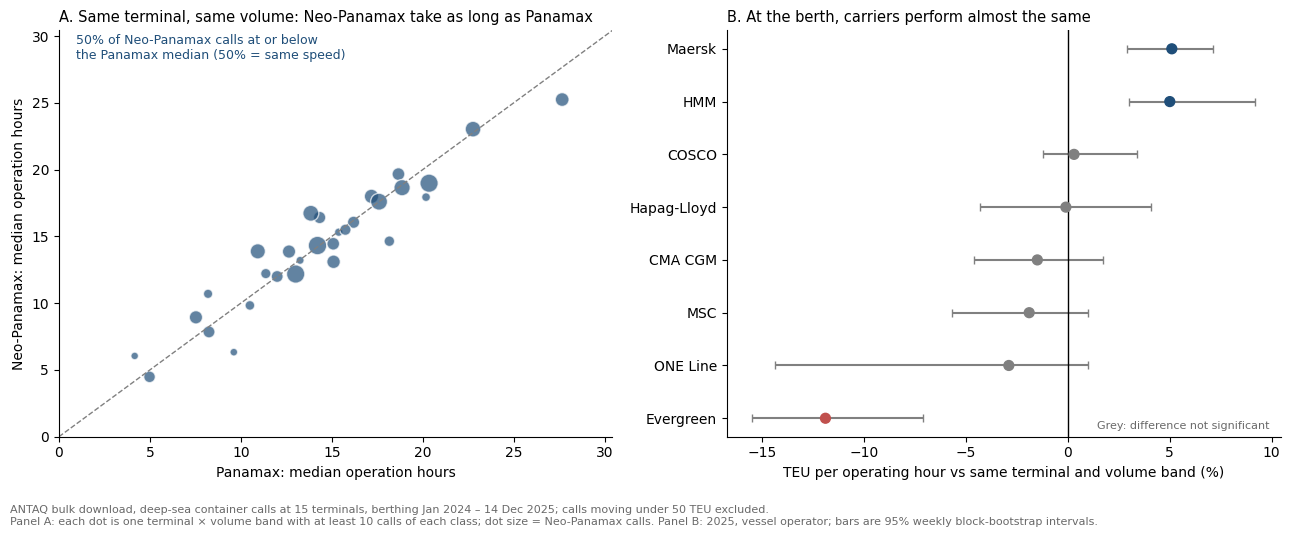

In [5]:
# 5 — Figure (fig11): berth time depends on volume and terminal, not on ship size or carrier
FIG_DIR = BASE / "outputs" / "figures"
rng = np.random.default_rng(42)
rk = (prod_ranking(pdf[pdf["year"] == 2025], "Armador_Operador")
      .drop(index=["Múltiplos"], errors="ignore").sort_values("vs_same_terminal_volume_%"))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

x, y = cell[("ops_h", "Panamax")], cell[("ops_h", "Neo-Panamax")]
size = cell[("calls", "Neo-Panamax")]
lim = [0, max(x.max(), y.max()) * 1.1]
ax1.plot(lim, lim, ls="--", lw=1, color="grey")
ax1.scatter(x, y, s=20 + size, color="#1f4e79", alpha=0.7, edgecolor="white")
ax1.set_xlim(lim)
ax1.set_ylim(lim)
ax1.set_xlabel("Panamax: median operation hours")
ax1.set_ylabel("Neo-Panamax: median operation hours")
ax1.set_title("A. Same terminal, same volume: Neo-Panamax take as long as Panamax", loc="left", fontsize=10.5)
ax1.text(0.03, 0.93, f"{100 * neo['at_or_below_panamax'].mean():.0f}% of Neo-Panamax calls at or below\n"
         "the Panamax median (50% = same speed)", transform=ax1.transAxes, fontsize=9, color="#1f4e79")

yy = np.arange(len(rk))
est = rk["vs_same_terminal_volume_%"]
sig_color = np.where(rk["CI_low_%"] > 0, "#1f4e79", np.where(rk["CI_high_%"] < 0, "#c0504d", "grey"))
ax2.errorbar(est, yy, xerr=[est - rk["CI_low_%"], rk["CI_high_%"] - est], fmt="none", ecolor="grey", capsize=3)
ax2.scatter(est, yy, color=sig_color, zorder=3, s=50)
ax2.axvline(0, color="black", lw=1)
ax2.set_yticks(yy, rk.index)
ax2.set_xlabel("TEU per operating hour vs same terminal and volume band (%)")
ax2.set_title("B. At the berth, carriers perform almost the same", loc="left", fontsize=10.5)
ax2.text(0.98, 0.02, "Grey: difference not significant", transform=ax2.transAxes,
         ha="right", fontsize=8, color="dimgrey")

for ax in (ax1, ax2):
    ax.spines[["top", "right"]].set_visible(False)

fig.text(0.01, -0.06,
         "ANTAQ bulk download, deep-sea container calls at 15 terminals, berthing Jan 2024 – 14 Dec 2025; calls moving under 50 TEU excluded.\n"
         "Panel A: each dot is one terminal × volume band with at least 10 calls of each class; dot size = Neo-Panamax calls. "
         "Panel B: 2025, vessel operator; bars are 95% weekly block-bootstrap intervals.",
         fontsize=8, color="dimgrey")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig11_berth_productivity.png", dpi=150, bbox_inches="tight")
plt.show()

## What this notebook answers

Deep-sea container calls at 15 terminals, berthing January 2024 to 14 December 2025; calls moving fewer than 50 TEU excluded. Operation time is the time between ANTAQ's logged start and end of cargo operations. All comparisons are made within the same terminal and the same band of TEU moved, because volume drives berth time far more than anything else.

- **Volume drives berth time.** Moving under 500 TEU takes about 2.2 operating hours per 100 TEU; moving over 5,000 TEU takes 0.6. Ten times the volume takes roughly five times the time.
- **A bigger ship is not faster at the berth.** At the same terminal and volume, Neo-Panamax calls take as long as Panamax calls: 50.1% of 2,081 Neo-Panamax calls finish at or below the Panamax median, where 50% means identical speed. The gain from larger ships is at sea, not at the quay.
- **Carriers perform almost the same once terminal and volume are fixed.** Maersk and HMM run about 5% faster, Evergreen about 12% slower, and the rest show no significant difference. Raw carrier rankings mostly reflect how many boxes each carrier moves per call.
- **A handful of Maersk Neo-Panamax ships beat the Panamax benchmark consistently** (for example, three San-class vessels finishing at or below it in 76–83% of 23–29 calls). With that many calls, chance is an unlikely explanation.
- **Portonave has the fastest operations (about 219 TEU per operating hour) and, per notebook 07, the longest waits.** Its bottleneck is before berthing, not at the quay.
- **MSC waits longer (notebook 07) but is as productive as the others at the berth.** Its disadvantage sits in the queue.

## Limitations

1. **Operation time is as logged by each terminal.** Recording practices can differ, which is why results compare calls within the same terminal. Portonave's high productivity is consistent across operation time and berth time, but has not been checked with the terminal.
2. **No crane data.** The number of cranes assigned to each call, the main driver of berth productivity, is not in ANTAQ.
3. **Operator, not container owner,** as in notebooks 06 and 07.
4. **The vessel-level list picks extremes,** and part of any top list is luck. Only vessels with many calls are informative.